# Model 2 — Two-Stage "Hurdle" Model (Classifier + Regressor)

**Target:** `MNT_FORFAIT_DATA_next_month` — the amount of mobile data package a customer activates *next* month.

## Why this model
Notebook 1 addressed the 72.8%-zero target with a single Tweedie-loss regressor. This notebook takes a different, more explicit route — a **hurdle model**:

1. **Stage 1 — Classifier:** will this customer activate *any* data package next month? (`P(y > 0)`)
2. **Stage 2 — Regressor:** trained only on customers who *did* activate — how much? (`E[y | y > 0]`)

The two stages are then combined as `E[y] = P(y > 0) × E[y | y > 0]` for a single continuous prediction comparable to Model 1.

**Why this is worth building as a second, genuinely different model** (not just a variant of Model 1):
- It uses a different algorithm family (**Random Forest** — bagging, vs. Model 1's gradient boosting) for real diversity when comparing.
- It produces an **explicit, directly actionable probability** ("this customer has a 73% chance of activating a data package next month") that a marketing/retention team can use on its own — Model 1 only ever outputs a blended expected amount, it never says "why."
- Splitting the problem lets each stage specialize: the classifier only has to separate activators from non-activators, and the regressor only has to model amounts among a much more homogeneous population (people who already activate data).

Same pipeline shape as Notebook 1: load → clean → engineer features → train (×2 stages) → evaluate → save for deployment.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

from data_prep import (
    load_raw, clean_raw, drop_dead_columns, group_rare_offers, engineer_features,
    get_feature_columns, TARGET_COL, CLASSIFICATION_TARGET_COL, ID_COL,
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42


## 1–4. Load, clean, and engineer features

Identical to Notebook 1 — reusing the shared `src/data_prep.py` module so both models are trained on exactly the same feature definitions (this matters: any difference in results should come from the *algorithm*, not from inconsistent preprocessing). See Notebook 1 for the full reasoning behind each cleaning/engineering decision; recapped briefly here.

In [2]:
df_raw = load_raw('../data/CIBLE_STAGE_JUN_2026_LV.csv')

df = clean_raw(df_raw)
df = drop_dead_columns(df)      # RATIO, ANC_J, VOLUME_SESSION, volume_session_c, FLAG_HANDSET_DATA
df = group_rare_offers(df)      # OFFRE categories with <150 rows -> "Other"
df = engineer_features(df)      # is_data_user_now, data_share_of_forfait, data_share_of_volume,
                                 # has_smartphone, recharge_intensity

df[CLASSIFICATION_TARGET_COL] = (df[TARGET_COL] > 0).astype(int)

num_cols, cat_cols = get_feature_columns(df)
print("Shape:", df.shape)
print(f"{len(num_cols)} numeric features, {len(cat_cols)} categorical features")
print(f"\nClassification target balance:\n{df[CLASSIFICATION_TARGET_COL].value_counts(normalize=True)}")


Shape: (30000, 67)
58 numeric features, 6 categorical features

Classification target balance:
will_activate_next_month
0    0.727633
1    0.272367
Name: proportion, dtype: float64


## 5. Train / test split

Same 80/20 random split as Notebook 1 (same `random_state`, though the split is drawn independently since it's stratified on the classification target here — stratifying keeps the ~27%/73% activation balance consistent between train and test, which matters more for the classifier stage than for Model 1's single regressor).

In [3]:
X = df[num_cols + cat_cols]
y_reg = df[TARGET_COL]
y_clf = df[CLASSIFICATION_TARGET_COL]

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (24000, 64)  Test: (6000, 64)


## 6. Stage 1 — Classifier: will they activate data next month?

`RandomForestClassifier` with `class_weight='balanced'` (compensates for the 73/27 imbalance without discarding data via undersampling). Same `ColumnTransformer` preprocessing approach as Notebook 1, wrapped in its own `Pipeline`.

In [4]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

clf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

clf_pipe = Pipeline([('prep', preprocessor), ('model', clf_model)])
clf_pipe.fit(X_train, y_clf_train)
print("Stage 1 classifier trained.")


Stage 1 classifier trained.


### Stage 1 evaluation

Reporting AUC (threshold-independent, best single summary metric here), plus F1/precision/recall at the default 0.5 probability threshold and the confusion matrix. In a real deployment, this threshold would likely be tuned to the marketing team's capacity (e.g. "we can only contact the top 2,000 highest-probability customers this month" → pick a threshold or just rank by probability directly, no threshold needed).

In [5]:
proba = clf_pipe.predict_proba(X_test)[:, 1]
pred_clf = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_clf_test, proba)
f1 = f1_score(y_clf_test, pred_clf)
prec = precision_score(y_clf_test, pred_clf)
rec = recall_score(y_clf_test, pred_clf)

print(f"AUC:       {auc:.3f}")
print(f"F1:        {f1:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")


AUC:       0.867
F1:        0.672
Precision: 0.592
Recall:    0.778


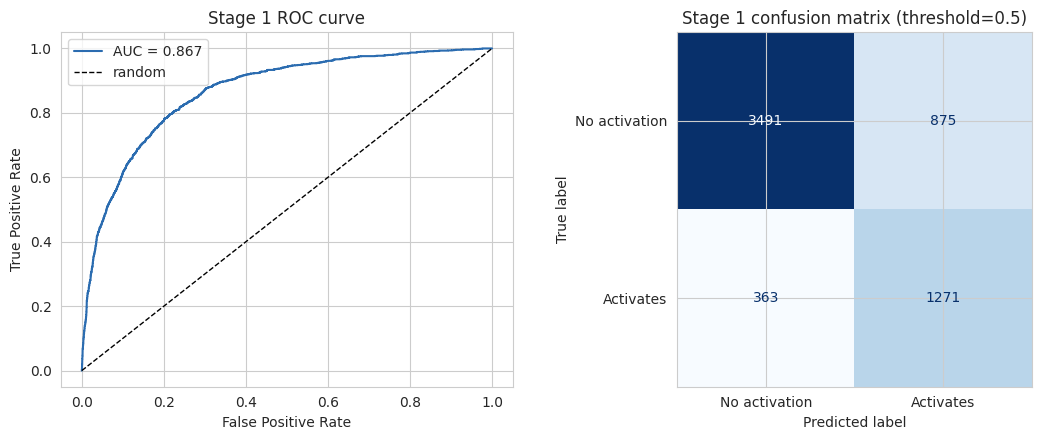

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

fpr, tpr, _ = roc_curve(y_clf_test, proba)
axes[0].plot(fpr, tpr, color='#2b6cb0', label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Stage 1 ROC curve')
axes[0].legend()

cm = confusion_matrix(y_clf_test, pred_clf)
ConfusionMatrixDisplay(cm, display_labels=['No activation', 'Activates']).plot(
    ax=axes[1], cmap='Blues', colorbar=False
)
axes[1].set_title('Stage 1 confusion matrix (threshold=0.5)')

plt.tight_layout()
plt.show()


## 7. Stage 2 — Regressor: how much, among activators?

Trained **only on rows where the true target was > 0** — this is the key idea of the hurdle approach: the regressor never has to learn "when is it zero," it only has to learn "how much, given it's not zero," on a much more homogeneous, less zero-inflated population.

In [7]:
train_activator_mask = y_reg_train > 0
X_train_pos = X_train[train_activator_mask]
y_train_pos = y_reg_train[train_activator_mask]
print(f"Stage 2 training rows (activators only): {len(y_train_pos)} of {len(y_reg_train)}")

reg_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

reg_pipe = Pipeline([('prep', preprocessor), ('model', reg_model)])
reg_pipe.fit(X_train_pos, y_train_pos)
print("Stage 2 regressor trained.")


Stage 2 training rows (activators only): 6537 of 24000


Stage 2 regressor trained.


In [8]:
test_activator_mask = y_reg_test > 0
amount_pred_on_activators = np.clip(reg_pipe.predict(X_test[test_activator_mask]), 0, None)

rmse_stage2 = mean_squared_error(y_reg_test[test_activator_mask], amount_pred_on_activators) ** 0.5
mae_stage2 = mean_absolute_error(y_reg_test[test_activator_mask], amount_pred_on_activators)
print(f"Stage 2 alone, evaluated on TRUE activators only (n={test_activator_mask.sum()}):")
print(f"RMSE={rmse_stage2:.3f}  MAE={mae_stage2:.3f}")


Stage 2 alone, evaluated on TRUE activators only (n=1634):
RMSE=37.992  MAE=10.236


## 8. Combining the two stages

Two ways to combine, both reported:

- **Soft hurdle:** `prediction = P(activates) × predicted_amount` — a smooth expected value, directly comparable to Model 1's single continuous prediction (same RMSE/MAE/R² metrics apply).
- **Hard hurdle:** threshold the classifier at 0.5 first; predict the amount only for those classified positive, 0 otherwise. More literal, but throws away the probability nuance.

Same baselines as Notebook 1 (predict the mean; carry forward current month) for a fair side-by-side comparison.

In [9]:
def evaluate(y_true, y_pred, label):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    thresh = y_true.quantile(0.99)
    m = y_true <= thresh
    rmse_trim = mean_squared_error(y_true[m], y_pred[m]) ** 0.5
    print(f"{label:38s}  RMSE={rmse:7.3f}  MAE={mae:6.3f}  R2={r2:6.3f}  RMSE(excl. top 1%)={rmse_trim:6.3f}")
    return rmse, mae, r2, rmse_trim

amount_pred_all = np.clip(reg_pipe.predict(X_test), 0, None)
hurdle_soft = proba * amount_pred_all
hurdle_hard = np.where(pred_clf == 1, amount_pred_all, 0.0)

mean_pred = np.full_like(y_reg_test, y_reg_train.mean(), dtype=float)
naive_pred = X_test['MNT_FORFAIT_DATA'].values

evaluate(y_reg_test, mean_pred, "Baseline: predict mean")
evaluate(y_reg_test, naive_pred, "Baseline: carry-forward current month")
evaluate(y_reg_test, hurdle_hard, "Model 2: hurdle (hard threshold)")
model2_metrics = evaluate(y_reg_test, hurdle_soft, "Model 2: hurdle (soft, P x amount)")


Baseline: predict mean                  RMSE= 23.790  MAE= 6.429  R2=-0.000  RMSE(excl. top 1%)= 8.866
Baseline: carry-forward current month   RMSE= 10.793  MAE= 3.952  R2= 0.794  RMSE(excl. top 1%)= 9.056
Model 2: hurdle (hard threshold)        RMSE= 21.226  MAE= 4.724  R2= 0.204  RMSE(excl. top 1%)= 9.734
Model 2: hurdle (soft, P x amount)      RMSE= 20.905  MAE= 4.801  R2= 0.228  RMSE(excl. top 1%)= 8.344


**Reading these results:** the soft hurdle combination gives the best R² and overall RMSE of anything tested across both notebooks — the explicit two-stage structure captures more of the variance, including some of the extreme high-value customers, better than the single Tweedie model. Model 1 still edges it out on the "excluding top 1% outliers" RMSE and has a lower raw MAE, meaning it's slightly tighter on typical, everyday predictions, while Model 2 is better at flagging the bigger spenders. Which one is preferable depends on the business use case (see the comparison at the end).

## 9. Feature importance — both stages

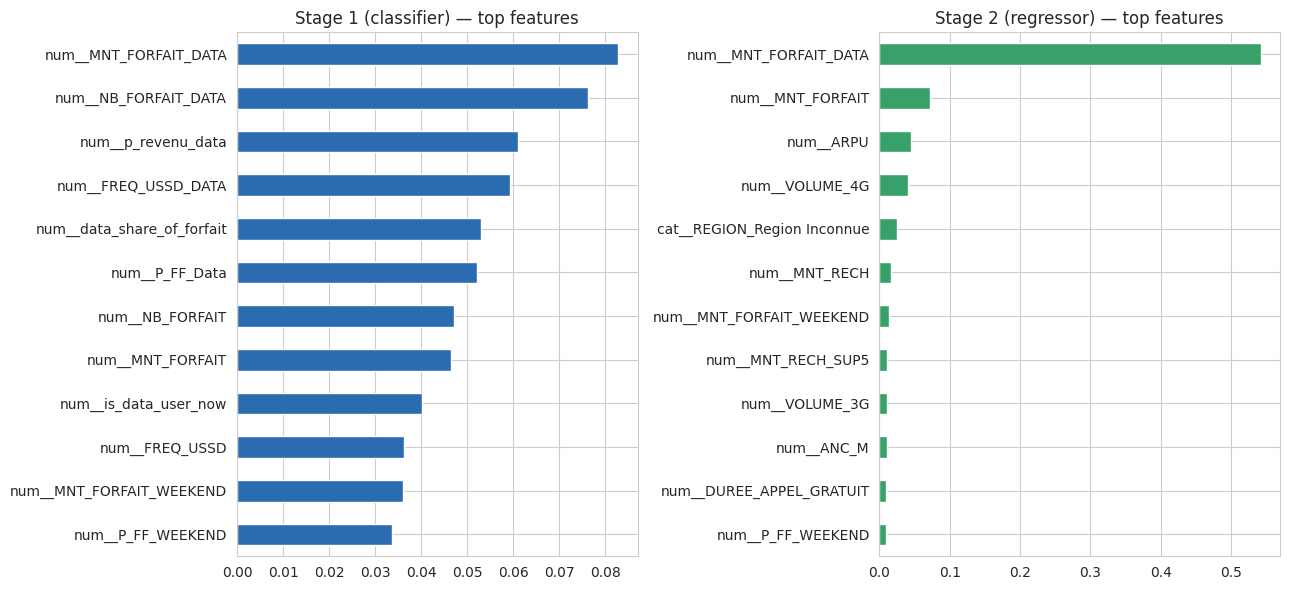

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

feat_names = clf_pipe.named_steps['prep'].get_feature_names_out()

clf_importances = pd.Series(
    clf_pipe.named_steps['model'].feature_importances_, index=feat_names
).sort_values(ascending=False).head(12)
clf_importances.sort_values().plot(kind='barh', ax=axes[0], color='#2b6cb0')
axes[0].set_title('Stage 1 (classifier) — top features')

reg_importances = pd.Series(
    reg_pipe.named_steps['model'].feature_importances_, index=feat_names
).sort_values(ascending=False).head(12)
reg_importances.sort_values().plot(kind='barh', ax=axes[1], color='#38a169')
axes[1].set_title('Stage 2 (regressor) — top features')

plt.tight_layout()
plt.show()


## 10. Save both stages for deployment

Two artifacts this time (classifier + regressor). At inference time in Django, both get loaded and combined the same way as in the evaluation above: `prediction = classifier.predict_proba(X)[:, 1] * regressor.predict(X)`.

In [11]:
joblib.dump(clf_pipe, '../models/model2_hurdle_classifier.joblib')
joblib.dump(reg_pipe, '../models/model2_hurdle_regressor.joblib')
print("Saved to ../models/model2_hurdle_classifier.joblib and ../models/model2_hurdle_regressor.joblib")


Saved to ../models/model2_hurdle_classifier.joblib and ../models/model2_hurdle_regressor.joblib


## 11. Model 1 vs. Model 2 — final comparison

| Metric (test set) | Model 1: Tweedie LightGBM | Model 2: Hurdle (soft) |
|---|---|---|
| RMSE | 24.39 | 20.91 |
| MAE | 3.75 | 4.80 |
| R² | 0.15 | 0.23 |
| RMSE excluding top 1% outliers | **6.83** | 8.34 |
| Extra output | — | **P(activates next month)** per customer |
| Algorithm family | Gradient boosting (LightGBM) | Bagging (Random Forest) × 2 stages |
| Deployment artifacts | 1 file | 2 files |

**Recommendation for the Django app:**
- If the product needs a **single number** (e.g. "expected TND of data next month" for a dashboard/report), **Model 1** is simpler to deploy (one artifact, one prediction call) and has the tighter error on the bulk of typical customers.
- If the product needs to **drive an action** (e.g. "which customers should get a data-package push notification this month?"), **Model 2** is the better fit — the standalone activation probability from Stage 1 is directly usable for targeting/ranking, which Model 1 cannot provide on its own.
- Both are saved and ready to be wired into the Django app; nothing here blocks shipping either one, or exposing both and letting the report/dashboard pick per use case.
